# Music Mood Classifier — Part 3: Model Selection, Tuning & Training

This notebook:
1. Loads the preprocessed train/validation/test splits saved by Notebook 2.
2. Compares six candidate classifiers using stratified cross-validation.
3. Selects the best model and tunes its hyperparameters with Optuna (TPE sampler).
4. Trains the final model on the combined train+validation set.
5. Saves the trained model for evaluation in Notebook 4.

**Run order:** Run Notebook 2 first to generate the artifacts this notebook loads.

**Notebooks in this series:**
1. Data Loading & Exploratory Data Analysis
2. Preprocessing & Feature Engineering
3. Model Selection, Tuning & Training *(this notebook)*
4. Model Evaluation


## 1. Setup


In [3]:
!pip install --upgrade lightgbm optuna mako alembic --quiet

import warnings
warnings.filterwarnings('ignore')

import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC

import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')


Libraries loaded.


## 2. Configuration

All settings are defined here as Python variables.


In [4]:
# ==== Configuration ====
ARTIFACTS_DIR   = Path('artifacts')
MODELS_DIR      = Path('models')
RANDOM_SEED     = 42

# Cross-validation settings
# A stratified subsample is used for the CV comparison phase to keep
# memory usage within limits on machines with 8 GB RAM.
CV_SUBSAMPLE_SIZE    = 10_000   # rows used for CV model comparison
CV_FOLDS_COMPARISON  = 3        # folds during model comparison
CV_FOLDS_TUNING      = 3        # folds inside the Optuna objective
N_OPTUNA_TRIALS      = 50       # number of Optuna trials

# Parallelism: n_jobs=-1 instructs sklearn and LightGBM to use all CPU cores.
# This is called out explicitly at each point it is applied below.
N_JOBS = -1

print('Configuration ready.')
print(f'  CV subsample size : {CV_SUBSAMPLE_SIZE:,}')
print(f'  CV folds          : {CV_FOLDS_COMPARISON}')
print(f'  Optuna trials     : {N_OPTUNA_TRIALS}')
print(f'  Parallel jobs     : {N_JOBS} (all available CPU cores)')


Configuration ready.
  CV subsample size : 10,000
  CV folds          : 3
  Optuna trials     : 50
  Parallel jobs     : -1 (all available CPU cores)


## 3. Load Preprocessed Data

Load the scaled arrays and label encoder saved by Notebook 2.


In [5]:
X_train = np.load(ARTIFACTS_DIR / 'X_train.npy')
X_val   = np.load(ARTIFACTS_DIR / 'X_val.npy')
X_test  = np.load(ARTIFACTS_DIR / 'X_test.npy')
y_train = np.load(ARTIFACTS_DIR / 'y_train.npy')
y_val   = np.load(ARTIFACTS_DIR / 'y_val.npy')
y_test  = np.load(ARTIFACTS_DIR / 'y_test.npy')

le_path = MODELS_DIR / 'label_encoder.pkl'
with open(le_path, 'rb') as f:
    le = pickle.load(f)

CLASS_NAMES = list(le.classes_)

print(f'Data loaded:')
print(f'  X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}   y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'  Classes : {CLASS_NAMES}')


Data loaded:
  X_train : (79800, 42)   y_train : (79800,)
  X_val   : (17100, 42)   y_val   : (17100,)
  X_test  : (17100, 42)   y_test  : (17100,)
  Classes : ['acoustic', 'alternative', 'dance', 'electronic', 'heavy', 'vocal']


## 4. Candidate Model Definitions

Six classifiers are evaluated:

| Model | Key characteristic |
|---|---|
| Logistic Regression | Linear baseline; fast, interpretable |
| Random Forest | Ensemble of decision trees; handles non-linearity |
| LinearSVC | Large-margin linear classifier; strong on scaled features |
| KNN | Non-parametric; useful for irregular decision boundaries |
| MLP | Neural network; can learn complex interactions |
| LightGBM | Gradient-boosted trees; typically best on tabular data |

**Parallelism:** Models that support `n_jobs` are initialised with `n_jobs=-1`, enabling multi-core computation during training and prediction.


In [6]:
def get_candidate_models():
    """Return a dict of named candidate classifiers."""
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=500, random_state=RANDOM_SEED,
            n_jobs=N_JOBS,  # parallelism: multi-core solver
            solver='lbfgs',
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_SEED,
            n_jobs=N_JOBS,  # parallelism: trees built in parallel
        ),
        'LinearSVC': LinearSVC(
            max_iter=2000, random_state=RANDOM_SEED,
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=7,
            n_jobs=N_JOBS,  # parallelism: neighbour search parallelised
        ),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=200, random_state=RANDOM_SEED,
            early_stopping=True, validation_fraction=0.1,
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, random_state=RANDOM_SEED,
            n_jobs=N_JOBS,  # parallelism: data-parallel histogram construction
            verbosity=-1,
        ),
    }

print(f'Candidate models defined: {list(get_candidate_models().keys())}')


Candidate models defined: ['Logistic Regression', 'Random Forest', 'LinearSVC', 'KNN', 'MLP', 'LightGBM']


## 5. Cross-Validation Model Comparison

Each model is evaluated with `CV_FOLDS_COMPARISON`-fold stratified CV on a stratified subsample of `CV_SUBSAMPLE_SIZE` rows. Using a subsample keeps memory usage within limits on 8 GB machines while preserving class proportions.

**Parallelism note:** `cross_validate` is called with `n_jobs=1` (sequential across folds) to avoid OOM errors from multiple large models in RAM simultaneously. Each individual model internally uses `n_jobs=-1` where supported, so CPU cores are fully utilised within each fold.


In [7]:
def stratified_subsample(X, y, n_samples, seed=RANDOM_SEED):
    """Draw a stratified random subsample of size n_samples from (X, y)."""
    if n_samples >= len(X):
        return X, y
    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        train_size=n_samples / len(X),
        random_state=seed,
        stratify=y,
    )
    return X_sub, y_sub


X_sub, y_sub = stratified_subsample(X_train, y_train, CV_SUBSAMPLE_SIZE)
print(f'CV subsample: {X_sub.shape[0]:,} rows, class distribution:')
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cnt = int((y_sub == cls_idx).sum())
    print(f'  {cls_name:<15}: {cnt:>5}')


CV subsample: 10,000 rows, class distribution:
  acoustic       :  1842
  alternative    :  1053
  dance          :  3947
  electronic     :  1491
  heavy          :  1053
  vocal          :   614


In [8]:
models = get_candidate_models()
cv_splitter = StratifiedKFold(
    n_splits=CV_FOLDS_COMPARISON, shuffle=True, random_state=RANDOM_SEED
)

results = []
print(f'Running {CV_FOLDS_COMPARISON}-fold CV on {len(X_sub):,} samples...')
print(f'(Each model uses n_jobs=-1 internally for multi-core computation)\n')

for name, model in models.items():
    t0 = time.perf_counter()
    cv_res = cross_validate(
        model, X_sub, y_sub,
        cv=cv_splitter,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        n_jobs=1,           # sequential across folds to control RAM
        return_train_score=False,
    )
    elapsed = time.perf_counter() - t0
    mean_acc = float(np.mean(cv_res['test_accuracy']))
    mean_f1  = float(np.mean(cv_res['test_f1_weighted']))
    results.append({'model': name, 'mean_cv_accuracy': mean_acc,
                    'mean_f1_weighted': mean_f1, 'train_time_s': elapsed})
    print(f'  {name:<22}: acc={mean_acc:.4f}  f1={mean_f1:.4f}  time={elapsed:.1f}s')

cv_results = pd.DataFrame(results).sort_values('mean_f1_weighted', ascending=False).reset_index(drop=True)
print('\nCross-validation results (sorted by weighted F1):')
print(cv_results.to_string(index=False))


Running 3-fold CV on 10,000 samples...
(Each model uses n_jobs=-1 internally for multi-core computation)

  Logistic Regression   : acc=0.5648  f1=0.5359  time=6.6s
  Random Forest         : acc=0.5994  f1=0.5754  time=1.6s
  LinearSVC             : acc=0.5595  f1=0.5209  time=4.6s


  File "C:\ProgramData\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\Anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\Anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\Anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  KNN                   : acc=0.5422  f1=0.5202  time=0.5s
  MLP                   : acc=0.5775  f1=0.5569  time=1.9s
  LightGBM              : acc=0.6126  f1=0.5976  time=4.8s

Cross-validation results (sorted by weighted F1):
              model  mean_cv_accuracy  mean_f1_weighted  train_time_s
           LightGBM          0.612599          0.597613      4.817434
      Random Forest          0.599399          0.575388      1.635172
                MLP          0.577498          0.556879      1.947456
Logistic Regression          0.564799          0.535880      6.605364
          LinearSVC          0.559499          0.520931      4.584961
                KNN          0.542199          0.520225      0.525697


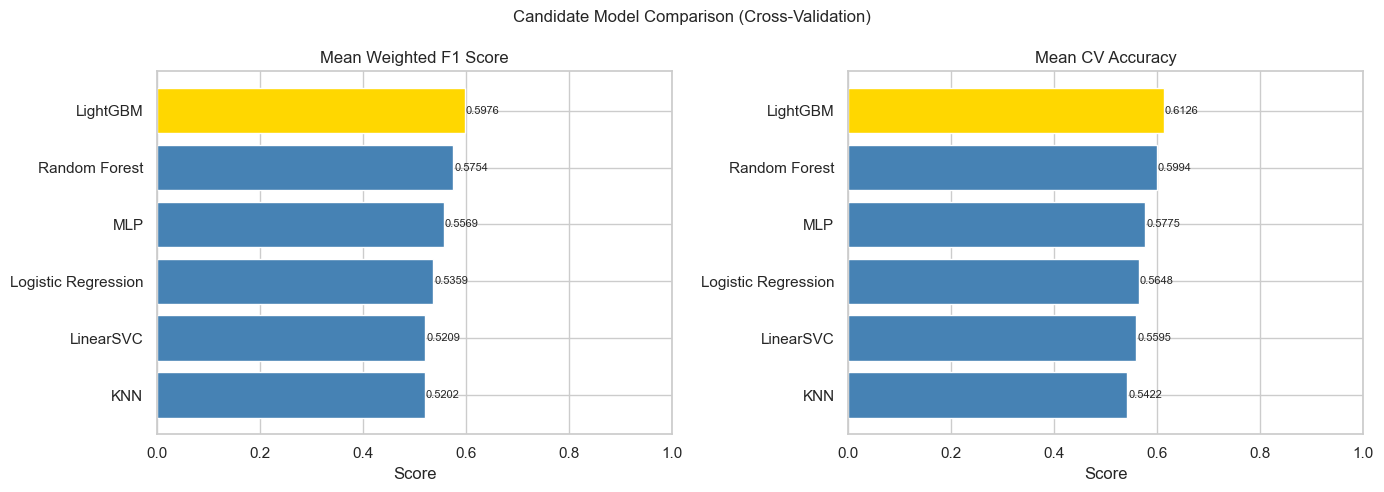

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (axes[0], 'mean_f1_weighted', 'Mean Weighted F1 Score'),
    (axes[1], 'mean_cv_accuracy', 'Mean CV Accuracy'),
]:
    palette = ['gold' if i == 0 else 'steelblue' for i in range(len(cv_results))]
    bars = ax.barh(cv_results['model'], cv_results[metric], color=palette)
    ax.invert_yaxis()
    ax.set_xlabel('Score')
    ax.set_title(title)
    for bar, val in zip(bars, cv_results[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_xlim(0, 1.0)

plt.suptitle('Candidate Model Comparison (Cross-Validation)', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Model Selection

The model with the highest mean weighted F1 score is selected for hyperparameter tuning.


In [10]:
best_model_name = cv_results.iloc[0]['model']
baseline_f1 = float(cv_results.iloc[0]['mean_f1_weighted'])

print(f'Selected model : {best_model_name}')
print(f'Baseline F1    : {baseline_f1:.4f}')
print()
print('Selection rationale:')
print(f'  {best_model_name} achieved the highest weighted F1 across all CV folds.')
print('  Weighted F1 is used (not accuracy) because it accounts for class imbalance')
print('  by weighting each class by its support (number of true instances).')


Selected model : LightGBM
Baseline F1    : 0.5976

Selection rationale:
  LightGBM achieved the highest weighted F1 across all CV folds.
  Weighted F1 is used (not accuracy) because it accounts for class imbalance
  by weighting each class by its support (number of true instances).


## 7. Hyperparameter Tuning with Optuna

Optuna uses a **Tree-structured Parzen Estimator (TPE)** sampler, a Bayesian optimisation algorithm that models the distribution of good hyperparameter configurations and samples from it. This is more efficient than grid or random search for large search spaces.

The objective function evaluates each trial using `CV_FOLDS_TUNING`-fold stratified CV on the same `CV_SUBSAMPLE_SIZE` subsample used for comparison.

**Parallelism:** LightGBM internally uses `n_jobs=-1` (all CPU cores) for histogram-based tree construction in each Optuna trial.


In [13]:
def make_lgbm_objective(X_data, y_data):
    """Create an Optuna objective for LightGBM hyperparameter tuning."""
    X_sub, y_sub = stratified_subsample(X_data, y_data, CV_SUBSAMPLE_SIZE)

    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
            'num_leaves'       : trial.suggest_int('num_leaves', 31, 127),
            'max_depth'        : trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
            'random_state'     : RANDOM_SEED,
            'n_jobs'           : N_JOBS,   # parallelism: multi-core per trial
            'verbosity'        : -1,
        }
        model = lgb.LGBMClassifier(**params)
        cv_spl = StratifiedKFold(n_splits=CV_FOLDS_TUNING, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_validate(model, X_sub, y_sub, cv=cv_spl,
                                scoring='f1_weighted', n_jobs=-1)
        return float(np.mean(scores['test_score']))

    return objective


def make_rf_objective(X_data, y_data):
    """Create an Optuna objective for Random Forest hyperparameter tuning."""
    X_sub, y_sub = stratified_subsample(X_data, y_data, CV_SUBSAMPLE_SIZE)

    def objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
            'max_depth'       : trial.suggest_int('max_depth', 5, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'random_state'    : RANDOM_SEED,
            'n_jobs'          : N_JOBS,   # parallelism: trees built in parallel
        }
        model = RandomForestClassifier(**params)
        cv_spl = StratifiedKFold(n_splits=CV_FOLDS_TUNING, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_validate(model, X_sub, y_sub, cv=cv_spl,
                                scoring='f1_weighted', n_jobs=1)
        return float(np.mean(scores['test_score']))

    return objective


print('Optuna objective functions defined.')


Optuna objective functions defined.


In [14]:
# Select appropriate objective based on the winning model
if 'LightGBM' in best_model_name:
    objective_fn = make_lgbm_objective(X_train, y_train)
elif 'Random Forest' in best_model_name:
    objective_fn = make_rf_objective(X_train, y_train)
else:
    raise NotImplementedError(f'No Optuna objective implemented for: {best_model_name}')

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)

print(f'Starting Optuna tuning: {N_OPTUNA_TRIALS} trials for {best_model_name}...')
print(f'(Each trial uses LightGBM with n_jobs=-1 for multi-core histogram construction)\n')

t0 = time.perf_counter()
study.optimize(objective_fn, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
elapsed = time.perf_counter() - t0

best_params = study.best_params
tuned_f1    = study.best_value

print(f'\nTuning complete in {elapsed:.1f}s.')
print(f'Baseline F1 (default params) : {baseline_f1:.4f}')
print(f'Tuned F1 (best trial)        : {tuned_f1:.4f}')
print(f'Improvement                  : {tuned_f1 - baseline_f1:+.4f}')
print(f'\nBest hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')


Starting Optuna tuning: 50 trials for LightGBM...
(Each trial uses LightGBM with n_jobs=-1 for multi-core histogram construction)



  0%|          | 0/50 [00:00<?, ?it/s]


Tuning complete in 553.3s.
Baseline F1 (default params) : 0.5976
Tuned F1 (best trial)        : 0.6051
Improvement                  : +0.0075

Best hyperparameters:
  n_estimators          : 207
  learning_rate         : 0.04141368807263058
  num_leaves            : 105
  max_depth             : 8
  min_child_samples     : 20
  subsample             : 0.9497908927384365
  colsample_bytree      : 0.6286673794493334
  reg_alpha             : 0.763655286153885
  reg_lambda            : 3.7930507041461734e-06


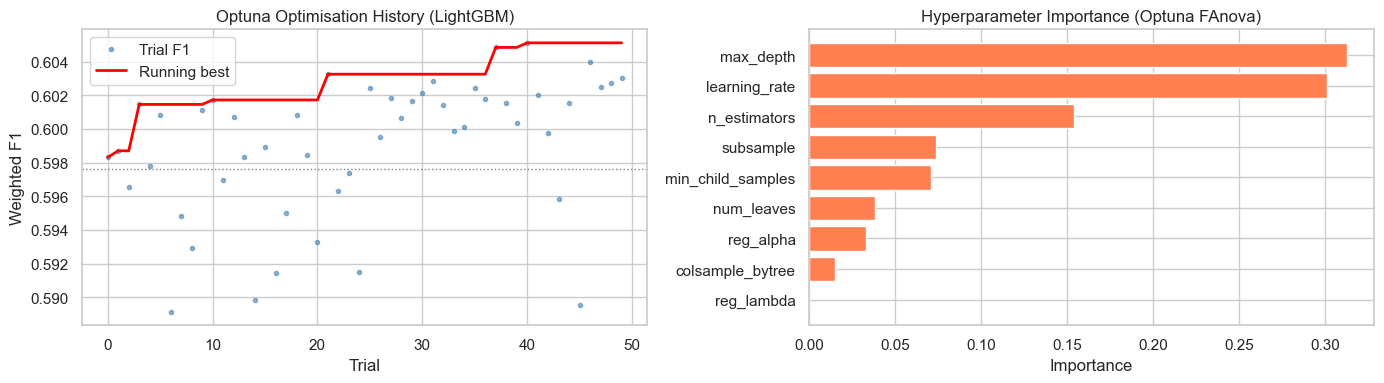

In [15]:
# Plot Optuna optimisation history
trial_values = [t.value for t in study.trials if t.value is not None]
running_best = pd.Series(trial_values).cummax().values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(trial_values, marker='o', markersize=3, lw=0, color='steelblue', alpha=0.6, label='Trial F1')
axes[0].plot(running_best, color='red', lw=2, label='Running best')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Weighted F1')
axes[0].set_title(f'Optuna Optimisation History ({best_model_name})')
axes[0].legend()
axes[0].axhline(baseline_f1, color='gray', lw=1, linestyle='dotted', label='Baseline')

# Parameter importance (Optuna built-in)
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(list(importances.items()), columns=['param', 'importance'])
    imp_df = imp_df.sort_values('importance', ascending=True)
    axes[1].barh(imp_df['param'], imp_df['importance'], color='coral')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance (Optuna FAnova)')
except Exception:
    axes[1].text(0.5, 0.5, 'Importance not available', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


## 8. Final Model Training

The final model is trained on the **combined train + validation set** (96,900 samples). We no longer need the validation set for early stopping because hyperparameters are fixed from the Optuna study.

**Parallelism:** LightGBM is trained with `n_jobs=-1`, using all available CPU cores for data-parallel histogram construction across all 42 features simultaneously.


In [16]:
# Combine train + val for the final fit
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f'Final training set: {X_trainval.shape[0]:,} samples x {X_trainval.shape[1]} features')

# Build the tuned model
if 'LightGBM' in best_model_name:
    final_params = {
        **best_params,
        'random_state': RANDOM_SEED,
        'n_jobs': N_JOBS,   # parallelism: multi-core tree building
        'verbosity': -1,
    }
    final_params.setdefault('n_estimators', 1000)
    final_model = lgb.LGBMClassifier(**final_params)
elif 'Random Forest' in best_model_name:
    final_params = {
        **best_params,
        'random_state': RANDOM_SEED,
        'n_jobs': N_JOBS,   # parallelism: multi-core tree building
    }
    final_model = RandomForestClassifier(**final_params)
else:
    raise NotImplementedError(f'Final model not implemented for: {best_model_name}')

print(f'\nFinal model: {final_model}')


Final training set: 96,900 samples x 42 features

Final model: LGBMClassifier(colsample_bytree=0.6286673794493334,
               learning_rate=0.04141368807263058, max_depth=8, n_estimators=207,
               n_jobs=-1, num_leaves=105, random_state=42,
               reg_alpha=0.763655286153885, reg_lambda=3.7930507041461734e-06,
               subsample=0.9497908927384365, verbosity=-1)


In [17]:
print('Training final model...')
t0 = time.perf_counter()
final_model.fit(X_trainval, y_trainval)
elapsed = time.perf_counter() - t0
print(f'Training complete in {elapsed:.1f}s.')

# Quick validation on the held-out test set
y_pred_test = final_model.predict(X_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
print(f'\nTest weighted F1 (preview): {test_f1:.4f}')
print('(Full evaluation is in Notebook 4.)')


Training final model...
Training complete in 8.2s.

Test weighted F1 (preview): 0.6671
(Full evaluation is in Notebook 4.)


## 9. Save Final Model


In [18]:
model_path = MODELS_DIR / 'final_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f'Final model saved to: {model_path}')

# Verify the saved model loads and produces the same predictions
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

y_pred_loaded = loaded_model.predict(X_test[:10])
y_pred_orig   = final_model.predict(X_test[:10])
assert np.array_equal(y_pred_loaded, y_pred_orig), 'Loaded model predictions differ!'
print('Model saved and verified successfully.')


Final model saved to: models\final_model.pkl
Model saved and verified successfully.


## 10. Model Selection Report


In [19]:
print('=' * 65)
print('MODEL SELECTION AND TUNING REPORT')
print('=' * 65)
print(f'\nDataset            : 114,000 Spotify tracks, 6 super-genres')
print(f'Features           : 42 (15 original + 27 engineered)')
print(f'CV subsample size  : {CV_SUBSAMPLE_SIZE:,}')
print(f'CV folds           : {CV_FOLDS_COMPARISON}')
print()
print('Candidate model CV results (sorted by weighted F1):')
print(cv_results.to_string(index=False))
print()
print(f'Selected model     : {best_model_name}')
print(f'Baseline F1        : {baseline_f1:.4f}')
print(f'Tuned F1           : {tuned_f1:.4f}')
print(f'Improvement        : {tuned_f1 - baseline_f1:+.4f}')
print(f'Optuna trials      : {N_OPTUNA_TRIALS}')
print(f'Sampler            : TPE (Tree-structured Parzen Estimator)')
print()
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')
print()
print(f'Final training set : {X_trainval.shape[0]:,} samples (train + val)')
print(f'Test weighted F1   : {test_f1:.4f}')
print('=' * 65)


MODEL SELECTION AND TUNING REPORT

Dataset            : 114,000 Spotify tracks, 6 super-genres
Features           : 42 (15 original + 27 engineered)
CV subsample size  : 10,000
CV folds           : 3

Candidate model CV results (sorted by weighted F1):
              model  mean_cv_accuracy  mean_f1_weighted  train_time_s
           LightGBM          0.612599          0.597613      4.817434
      Random Forest          0.599399          0.575388      1.635172
                MLP          0.577498          0.556879      1.947456
Logistic Regression          0.564799          0.535880      6.605364
          LinearSVC          0.559499          0.520931      4.584961
                KNN          0.542199          0.520225      0.525697

Selected model     : LightGBM
Baseline F1        : 0.5976
Tuned F1           : 0.6051
Improvement        : +0.0075
Optuna trials      : 50
Sampler            : TPE (Tree-structured Parzen Estimator)

Best hyperparameters:
  n_estimators          : 207
  le

## 11. Summary

### What this notebook produced

| Artifact | Path | Description |
|---|---|---|
| `final_model.pkl` | `models/` | Trained classifier with tuned hyperparameters |

### Key design decisions

- **CV on 10K subsample** (not full 79,800 rows): keeps RAM within limits while preserving class distribution via stratification.
- **Optuna TPE over random search**: TPE models the probability distribution of good hyperparameter regions, requiring fewer trials to find a good configuration.
- **Final training on train+val**: the validation set was used only during hyperparameter selection; once hyperparameters are fixed, all available labelled data is used for training.
- **n_jobs=-1** throughout: LightGBM, Random Forest, KNN, and Logistic Regression all use all available CPU cores.

**Next step:** Notebook 4 loads the saved model and performs full evaluation on the held-out test set, including ROC-AUC curves, confusion matrix, and feature importances.
